# 06_error_analysis — Diagnóstico de Errores y Estrategia Híbrida

**Objetivo:** Entender *por qué* y *dónde* fallan nuestros modelos para diseñar una estrategia híbrida efectiva.

**Preguntas Clave:**
1. ¿En qué casos acierta BETO y fallan las reglas (y viceversa)?
2. ¿Cuántos "falsos positivos" de las reglas son realmente aciertos (errores de anotación)?
3. ¿Existe un patrón léxico claro en los errores de BETO?

**Inputs:**
- Modelo BETO entrenado (`data/checkpoints/beto/checkpoint-189`)
- Dataset Dev Full (`dev_full.csv`)
- Señal Clínica/Reglas (`dataset_with_clinical_signal_flag.csv`)


In [11]:
# ===============================================================
# Setup: Imports y configuración
# ===============================================================
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from datasets import Dataset
from sklearn.metrics import confusion_matrix, classification_report
import torch

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Importar utilidades compartidas
try:
    from utils_shared import setup_paths, load_splits, calculate_metrics
    paths = setup_paths()
    DATA_PATH = paths['DATA_PATH']
    SPLITS_PATH = paths['SPLITS_PATH']
    FIGS_PATH = paths['FIGS_PATH']
    print("[OK] Usando utils_shared.py")
except ImportError:
    print("[ERROR] No se encontró utils_shared.py")
    raise

[OK] Usando utils_shared.py


## 1) Cargar Datos y Modelo

In [12]:
# 1. Cargar Dev Set
df_base, _, dev_idx, _ = load_splits(SPLITS_PATH)
df_dev = df_base.set_index('row_id').loc[dev_idx].reset_index()

# [FIX] Limpiar NaNs en texto para evitar error en Tokenizer
nan_count = df_dev['texto'].isna().sum()
if nan_count > 0:
    print(f"⚠️ Se encontraron {nan_count} valores nulos en 'texto'. Reemplazando por string vacío.")
    df_dev['texto'] = df_dev['texto'].fillna("").astype(str)

print(f"Dataset Dev: {len(df_dev)} casos")

# 2. Cargar Metadata de Reglas (Signal Flag)
df_rules = pd.read_csv(DATA_PATH / 'dataset_with_clinical_signal_flag.csv')
# Mapear por row_id
rule_map = df_rules.set_index('row_id')['has_signal'].to_dict()
df_dev['has_signal'] = df_dev['row_id'].map(rule_map)
# Si has_signal es True -> Predicimos la clase positiva (ej: ansiedad/depresion)
# OJO: has_signal solo dice "tiene palabras clave". 
# Para simplificar, asumiremos que si tiene señal, la regla predice la clase target (1).
# Si no tiene señal, predice la clase control (0).
df_dev['has_signal_int'] = df_dev['has_signal'].astype(int)

# 3. Cargar Modelo BETO
checkpoint_path = DATA_PATH / 'checkpoints/beto/checkpoint-189' # Ajustar si es necesario
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cargando modelo desde: {checkpoint_path}")

tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path).to(device)
print("Modelo cargado correctamente.")

⚠️ Se encontraron 1 valores nulos en 'texto'. Reemplazando por string vacío.
Dataset Dev: 627 casos
Cargando modelo desde: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/checkpoints/beto/checkpoint-189
Modelo cargado correctamente.


## 2) Inferencia con BETO en Dev Set

In [13]:
# Preprocesar para el modelo
def tokenize_function(examples):
    return tokenizer(examples["texto"], padding="max_length", truncation=True, max_length=512)

ds_dev = Dataset.from_pandas(df_dev[['texto']])
tokenized_dev = ds_dev.map(tokenize_function, batched=True)

# Trainer para predicción
trainer = Trainer(model=model)
preds_output = trainer.predict(tokenized_dev)
y_preds_logits = preds_output.predictions
y_preds_beto = np.argmax(y_preds_logits, axis=1)

df_dev['beto_pred'] = y_preds_beto

# Mapear etiquetas reales a int si no lo están
label2id = {'depresion': 0, 'ansiedad': 1} # Ajustar según tu dataset
# VALIDAR PRIMERO: ¿Cómo están tus etiquetas en df_dev?
print(f"Etiquetas reales: {df_dev['etiqueta'].unique()}")
# Asumimos que 0 es la clase "positiva" para el análisis o viceversa.
# IMPORTANTE: Revisar id2label del modelo cargado
print(f"Config del modelo: {model.config.id2label}")

# Normalizar columna 'target' (int)
df_dev['target'] = df_dev['etiqueta'].map(label2id)

print("Inferencia completada.")

# [FIX] Definir id2label para uso posterior
id2label = {v: k for k, v in label2id.items()}

Map: 100%|██████████| 627/627 [00:00<00:00, 4409.41 examples/s]
/Users/manuelnunez/Projects/psych-phenotyping-paraguay/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Etiquetas reales: ['ansiedad' 'depresion']
Config del modelo: {0: 'depresion', 1: 'ansiedad'}
Inferencia completada.


## 3) Comparación: BETO vs Reglas vs Realidad

Análisis de Coincidencia:


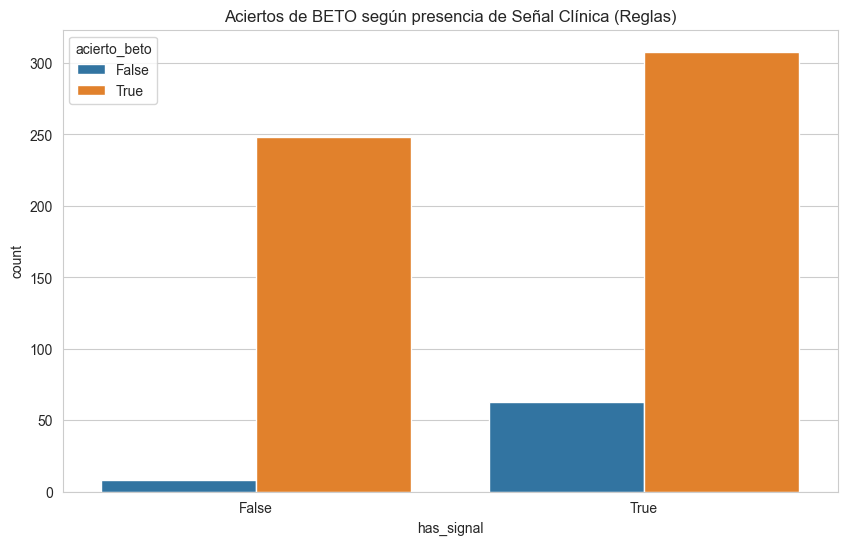

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de Confusión BETO
cm_beto = confusion_matrix(df_dev['target'], df_dev['beto_pred'])
disp_beto = ConfusionMatrixDisplay(confusion_matrix=cm_beto, display_labels=list(label2id.keys()))

# Matriz de Confusión Reglas (Rule-Based)
# Nota: Las reglas de 'has_signal' son binarias (Tiene/No Tiene). 
# Pero tus etiquetas son 'depresion' vs 'ansiedad'. 
# Si has_signal=True, ¿qué predice? 
# ESTO ES UN PUNTO CLAVE: El denoising actual filtra textos SIN señal clínica.
# Asumimos que si has_signal=False -> Es ruido -> El modelo debería predecir... ¿qué?
# En este caso, como es clasificación binaria Depresión/Ansiedad, 'has_signal' no distingue entre ellas.
# 'has_signal' distingue entre 'Enfermo' vs 'Sano/Ruido' O simplemente 'Texto Útil' vs 'Inútil'.
# 
# REVISIÓN: Tu tarea es clasificar entre Depresión y Ansiedad.
# El Denoising elimina textos que NO hablan de ningun síntoma.
# Por tanto, el análisis de error de reglas debe enfocarse en:
# ¿El texto ELIMINADO por reglas (signal=False) tenía etiqueta real?
# Pero en tu dev set, asumo que TODO es relevante? O hay ruido?

print("Análisis de Coincidencia:")
df_dev['acierto_beto'] = df_dev['target'] == df_dev['beto_pred']

# Verificamos si la señal (Denoising) correlaciona con el acierto de BETO
sns.countplot(data=df_dev, x='has_signal', hue='acierto_beto')
plt.title("Aciertos de BETO según presencia de Señal Clínica (Reglas)")
plt.show()

## 4) Inspección de Errores

Veamos los textos donde BETO falla pero las reglas dicen que hay señal.

In [15]:
errores_beto = df_dev[~df_dev['acierto_beto']]
print(f"Total Errores BETO: {len(errores_beto)}")

print("\nEjemplos de errores con Señal Clínica Fuerte (Rule=True):")
for i, row in errores_beto[errores_beto['has_signal'] == True].head(5).iterrows():
    print(f"--- ID: {row['row_id']} ---")
    print(f"Texto: {row['texto'][:200]}...")
    print(f"Real: {row['etiqueta']} | Pred: {id2label[row['beto_pred']]}")
    print("")

Total Errores BETO: 71

Ejemplos de errores con Señal Clínica Fuerte (Rule=True):
--- ID: 75 ---
Texto: Paciente acude en silla de ruedas. Abordable y colaboradora. Realiza Paciente acude en silla de ruedas. Realiza contacto visual. Conductualmente estable. Atiende y comprende. Humor ansioso, afecto aco...
Real: ansiedad | Pred: depresion

--- ID: 80 ---
Texto: paciente acude sin cita, consulta con la dra claudia samudio. refiere despertares precoces, se despierta a las 2am, refiere que dormia mejor con la quetiapina, pero no podia comprarla cuando hizo falt...
Real: ansiedad | Pred: depresion

--- ID: 87 ---
Texto: MC: Control evolutivo MC: Control evolutivo APP Hace 6 meses sufre ACV dejando secuelas de hemiparesia lado izquierdo MC: Control evolutivo APP Hace 6 meses sufre ACV dejando secuelas de hemiparesia l...
Real: ansiedad | Pred: depresion

--- ID: 112 ---
Texto: MC: no mejoro de la ansiedad, estoy peor MC: no mejoro de la ansiedad, estoy peor FXT 20 2 0 0 QTP 100 0 0 1/2 MC: 